# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-50 Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-50 model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [2]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet50, DropoutRateScheduler
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

# Core Variables

In [3]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Path variables
DATA_PATH = '../data/'                                          # Path to the dataset
OUTPUT_PATH = '../output/'                                      # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'                            # Path to save the model
MODEL_NAME = 'resnet_50_augmented'                              # Name of the model to be saved
LOG_PATH = OUTPUT_PATH + 'logs/'+ MODEL_NAME + '_info.json'     # Path to save model metrics

# Ensure directories exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

In [4]:
# Training parameters
EPOCHS = 100                # Number of epochs to train
BATCH_SIZE = 96             # Batch size for training
LEARNING_RATE = 0.001       # Learning rate for the optimizer

# Dropout parameters
DROPOUT_MODE = "custom"     # Dropout mode: "fixed" or "custom"
DROPOUT_RATE = 0.3          # Fixed dropout rate
DROPOUT_RATE_START = 0.5    # Starting rate for scheduler
DROPOUT_RATE_END = 0.3      # Ending rate for scheduler

# Model selection parameters
CHOSEN_METRIC = 'val_AUC'   # Metric to be used for model selection
MODE = 'max'                # Whether to maximize or minimize the chosen metric

# Final model path
if DROPOUT_MODE == "fixed":
    FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_dr{DROPOUT_RATE}_pneumonia_model.keras'
elif DROPOUT_MODE == "custom":
    FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_dr{DROPOUT_RATE_START}_{DROPOUT_RATE_END}_pneumonia_model.keras'

# Create model logger
logger = ModelLogger()

# Data Loading & Preprocessing

In [5]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH,
        augment=True,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


# ResNet-50 Model

## Creation & Compilation

In [6]:
# Initialize model info for logging
model_info = {
    "model_name": MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "dropout_mode": DROPOUT_MODE,
    "dropout_rate": DROPOUT_RATE if DROPOUT_MODE == "fixed" else None,
    "dropout_start": DROPOUT_RATE_START if DROPOUT_MODE == "custom" else None,
    "dropout_end": DROPOUT_RATE_END if DROPOUT_MODE == "custom" else None,
    "random_seed": RANDOM_SEED
}

# Initialize logger with model info
logger.initialize_run(model_info)

In [7]:
# Create and compile model
if DROPOUT_MODE == "fixed":
    model = build_resnet50(dropout_rate=DROPOUT_RATE)
elif DROPOUT_MODE == "custom":
    model = build_resnet50(dropout_rate=DROPOUT_RATE_START)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │      4,160 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv3 │ (None, 14, 14,    │     16,640 │ stage1_block1_re… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 14, 14,    │     16,640 │ maxpool1[0][0]    │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn3   │ (None, 14, 14,    │      1,024 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_shor… │ (None, 14, 14,    │      1,024 │ stage1_block1_sh… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 256)              │            │ stage1_block1_sh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu3 │ (None, 14, 14,    │          0 │ stage1_block1_ad

 Total params: 23,582,978 (89.96 MB)

 Trainable params: 23,529,858 (89.76 MB)

 Non-trainable params: 53,120 (207.50 KB)

## Training

In [8]:
# Get callbacks
callbacks = get_callbacks(FINAL_MODEL_PATH, monitor=CHOSEN_METRIC, mode=MODE)

# Add dropout scheduler callback if using custom scheduler
if DROPOUT_MODE == "custom":
    dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)
    callbacks.append(dropout_scheduler)

In [9]:
# Train model
start_time = time.time()

history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=tf_verbosity
    )

exec_time = round(time.time() - start_time, 2)
print(f"\nModel training completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

Epoch 1: dropout rate set to 0.5000
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 109s 909ms/step - AUC: 0.8483 - accuracy: 0.7968 - loss: 0.7454 - val_AUC: 0.7570 - val_accuracy: 0.7424 - val_loss: 0.6031 - learning_rate: 0.0010
Epoch 2: dropout rate set to 0.4980
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - AUC: 0.9508 - accuracy: 0.8971 - loss: 0.3258 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 0.9772 - learning_rate: 0.0010
Epoch 3: dropout rate set to 0.4960
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - AUC: 0.9760 - accuracy: 0.9298 - loss: 0.1741 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 4: dropout rate set to 0.4940
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - AUC: 0.9687 - accuracy: 0.9140 - loss: 0.2291 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 2.5438 - learning_rate: 0.0010
Epoch 5: dropout rate set to 0.4920
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - AUC: 0.9781 - accura

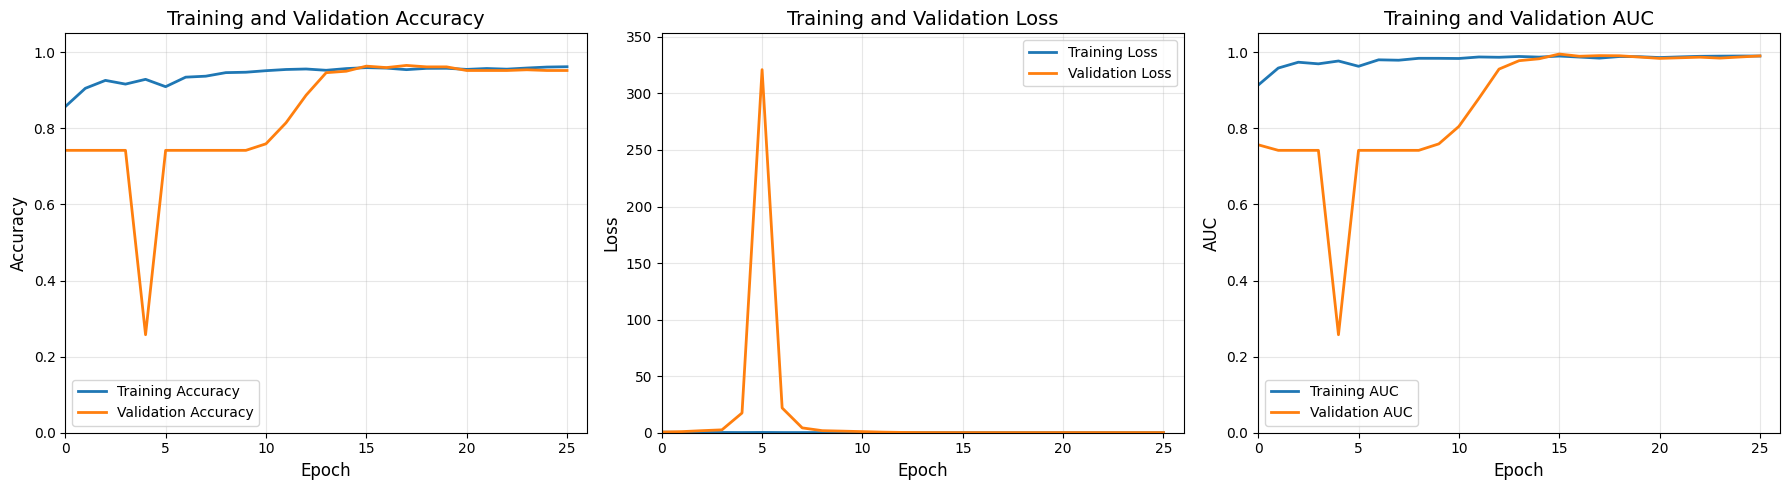

In [10]:
# Plot training history
plot_training_history(history)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - AUC: 0.9328 - accuracy: 0.8637 - loss: 0.3386
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step


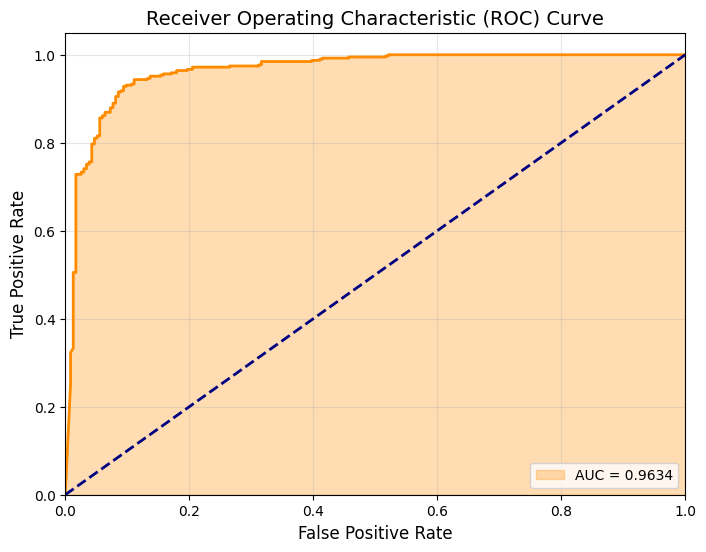

ROC AUC Score: 0.963434


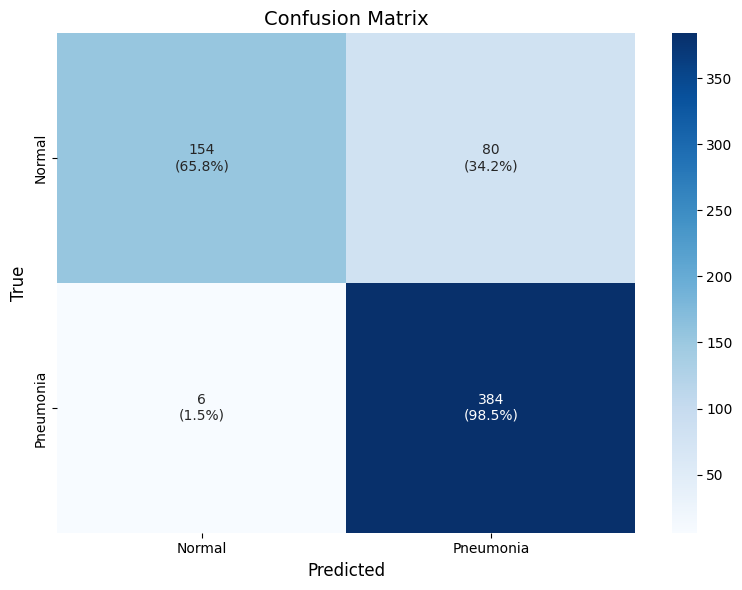

              precision    recall  f1-score   support

      Normal       0.96      0.66      0.78       234
   Pneumonia       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.82      0.84       624
weighted avg       0.88      0.86      0.86       624



In [11]:
# Evaluate model with reduced verbosity
results = evaluate_model(model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

## Checkpointing

In [12]:
# Save all model information
logger.save(LOG_PATH)

# Save final model
model.save(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Run information saved to ../output/logs/resnet_50_augmented_info.json
Model saved to ../output/models/resnet_50_augmented_b96_lr0.001_dr0.5_0.3_pneumonia_model.keras
